## Generate the activity of place cells on a linear track

In [1]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets

track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

# GENERATE TRAJECTORY
n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])

for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

import pickle

file_name = 'linear_track_data_new.pickle' 

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)

In [2]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# Exercise 1

## A: Change in sample size

100%|███████████████████████████████████████| 671/671 [00:00<00:00, 1009.79it/s]


Median error: 89.48713770904965 cm


100%|█████████████████████████████████████| 1342/1342 [00:01<00:00, 1036.49it/s]


Median error: 72.58739079734664 cm


100%|█████████████████████████████████████| 3355/3355 [00:03<00:00, 1027.48it/s]


Median error: 13.595744680851055 cm


100%|█████████████████████████████████████| 5368/5368 [00:05<00:00, 1037.06it/s]


Median error: 4.844968268359025 cm


100%|█████████████████████████████████████| 6711/6711 [00:06<00:00, 1042.83it/s]


Median error: 3.784810126582272 cm


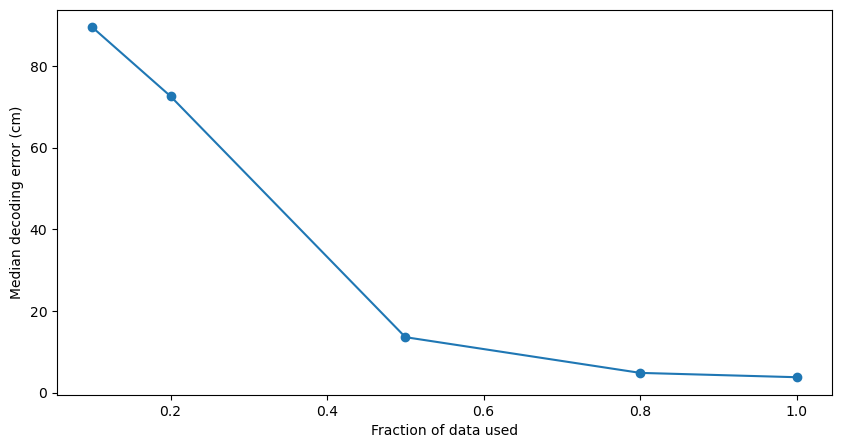

In [3]:
# code decoding
from scipy.stats import poisson
from tqdm import tqdm
import seaborn as sns

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes: so size (4715,)
decoding_times = t[:-1]

#getting different fractions of our data samples
fractions = [0.1, 0.2, 0.5, 0.8, 1.0]
medians = []
for frac in fractions:
    decoding_times_fraction = np.random.choice(np.arange(len(decoding_times)), size=int(frac * len(decoding_times)),replace=False)
    x_decoded = np.zeros_like(true_x)
    
    for t_bin in tqdm(range(len(decoding_times_fraction))):
        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps.shape[-1])
    
            for i in range(len(posterior)):
                # Note that we work with log so that we can sum probabilities
                # instead of multiplying them 
                posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15)) 
            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan   

    mse = np.sqrt((true_x-x_decoded)**2)
    print(f"Median error: {np.nanmedian(mse)} cm")
    medians.append(np.nanmedian(mse))

plt.plot(fractions, medians, marker='o')
plt.xlabel("Fraction of data used")
plt.ylabel("Median decoding error (cm)")
plt.show()

> As the data samples increases, the median error descreases rapidly. It looks like the sample size of the data has a very big effect on the decoding.

## B: Change in number of cells


100%|█████████████████████████████████████| 6711/6711 [00:01<00:00, 3397.55it/s]


Median error: 8.690607734806633 cm


100%|█████████████████████████████████████| 6711/6711 [00:03<00:00, 1803.45it/s]


Median error: 7.721698113207552 cm


100%|█████████████████████████████████████| 6711/6711 [00:04<00:00, 1610.09it/s]


...

Median error: 5.106224855507705 cm


100%|█████████████████████████████████████| 6711/6711 [00:06<00:00, 1063.13it/s]


Median error: 4.095194922937438 cm


100%|█████████████████████████████████████| 6711/6711 [00:06<00:00, 1004.58it/s]


Median error: 3.784810126582272 cm


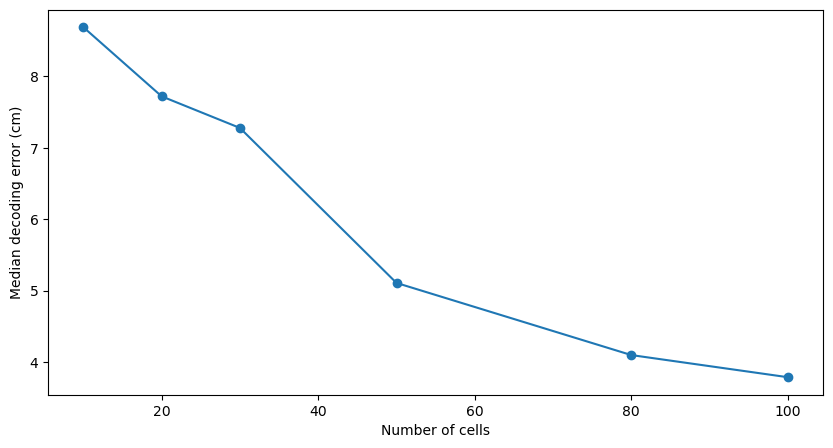

In [4]:
#getting data for different amount of cells
cells = [10, 20, 30, 50, 80, 100]
medians = []
for n in cells:
    selected_cells = np.random.choice(np.arange(n_cells), size=n, replace=False)

    #subset data, spikes_count shape: (time, n_cells), firing_rate_maps shape: (n_cells, n_space_bins)
    firing_rate_maps_subset = firing_rate_maps[selected_cells, :]
    spikes_count_subset = spikes_count[:, selected_cells]
    
    x_decoded = np.zeros_like(true_x)
    
    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count_subset[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps_subset.shape[-1])
    
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_count_subset[t_bin,:],firing_rate_maps_subset[:,i]/fps)+pow(10,-15)) 
            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan   

    mse = np.sqrt((true_x-x_decoded)**2)
    print(f"Median error: {np.nanmedian(mse)} cm")
    medians.append(np.nanmedian(mse))

plt.plot(cells, medians, marker='o')
plt.xlabel("Number of cells")
plt.ylabel("Median decoding error (cm)")
plt.show()

> We see that an increase of the number of cells we look at, decreases the median error. Meaning that looking at a broader collection of cells gives us much better information of the position of the animal. We can also note that the decoding is not as much effecter by the number of cells compared to the sample size (see 1A)

## C: Change of firing rate noise

In [5]:
def Noise(noise_firing_rate):
    track_length = 200. # the length of our linear track (eg in centimeter)
    average_firing_rate = 5 # the peak firing rate, averaged across the population 
    n_cells = 100 # how many cells we are recording
    pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
    pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
    pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution
    
    bins = np.arange(0., 200.)
    true_firing_rate_maps = np.zeros((n_cells, len(bins)))
    for i in range(n_cells):
        true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
    
    # GENERATE TRAJECTORY
    n_runs = 10
    use_stops = False
    av_running_speed = 10 # the average running speed (in cm/s)
    fps = 10 # the number of "video frames" per second 
    running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
    running_speed_b = np.random.chisquare(10, size=n_runs) 
    
    stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
    stopping_time_b = np.random.chisquare(15, size=n_runs)
    
    x = np.array([])
    
    for i in range(n_runs):
        stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
        run_length = len(bins) * fps / running_speed_a[i]
        run1 = np.linspace(0., float(len(bins)-1), int(run_length))
        stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
        run_length = len(bins) * fps / running_speed_b[i]
        run2 = np.linspace(len(bins)-1., 0., int(run_length))
        if use_stops:
            x = np.concatenate((x, stop1, run1, stop2, run2))
        else:
             x = np.concatenate((x, run1, run2))
    t = np.arange(len(x))/fps
    
    sampling_rate = 10000.
    t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
    x_sampling = np.floor(np.interp(t_sampling, t, x))
    #noise_firing_rate = 0.1 the baseline noise firing rate --> CHANGED
    spikes = []
    
    for i in range(n_cells):
        inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
        spikes_loc = np.random.poisson(inst_rate/sampling_rate)
        sp = np.argwhere(spikes_loc)
        t_sp = t_sampling[sp]
        spikes.append(t_sp)
    
    file_name = 'linear_track_data_new_noise.pickle' 
    
    out_data = {}
    out_data['x'] = x
    out_data['t'] = t
    out_data['spikes'] = spikes
    out_data['track_length'] = track_length
    out_data['fps'] = fps
    
    with open('data/'+file_name,'wb') as f:
        pickle.dump(out_data,f)
    
    # we compute the poistion at which each spike was emitted
    spike_positions = [np.interp(s, t, x) for s in spikes]
    space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms
    
    # we compute histograms for each cell
    spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
    spikes_hist = np.asarray(spikes_hist)
    
    # we also need an "occupancy histogram" in order to normalize the firing rates maps 
    occupancy = np.histogram(x, space_bins)[0] /  fps
    
    firing_rate_maps = spikes_hist / occupancy 
    
    spikes_count= [np.histogram(s,t)[0] for s in spikes]
    spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape
    
    # code decoding
    true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
    decoding_times = t[:-1]
    
    x_decoded = np.zeros_like(true_x)
    
    for t_bin in tqdm(range(len(decoding_times))):
        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
            posterior = np.empty(firing_rate_maps.shape[-1])
    
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))
    
    
            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan   
    
    # error distribution
    mse = np.sqrt((true_x-x_decoded)**2)
    print(f'Median error: {np.nanmedian(mse)} cm')

noise=[1.,10., 100.]
for noise_firing_rate in noise:
    Noise(noise_firing_rate)

100%|█████████████████████████████████████| 6232/6232 [00:06<00:00, 1013.53it/s]


Median error: 4.501412429378533 cm


100%|█████████████████████████████████████| 4860/4860 [00:04<00:00, 1010.38it/s]


Median error: 10.097244500986406 cm


100%|█████████████████████████████████████| 4997/4997 [00:04<00:00, 1004.46it/s]

Median error: 38.50467289719626 cm


> From exercise 1A we got for noise_firing_rate of 0.1 a median error of 3.784810126582272 cm. We see that as the noise increases, the median error also increases. This makes sense since a lot of disturbances (high noise) in the data makes it harder to decode (high median error). However the relative effect of the noise ofcourse depends on the ratio of the noise and the measured activity of the cells.



# Exercise 2

In [6]:
track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

# GENERATE TRAJECTORY
n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])

for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 #the baseline noise firing rate 
spikes = []

for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

file_name = 'linear_track_data_new_ex2.pickle' 

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)

# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

# code decoding
true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

In [9]:
x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            #posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))

        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
print(f'Median error: {np.nanmedian(mse)} cm')

100%|██████████████████████████████████████| 5276/5276 [00:05<00:00, 900.78it/s]

Median error: 5.188405797101467 cm


> We see that the median error is bigger then the previous one we had. The reason for this likely lies in the +1^-15(=1 and which is also different then the +10^-15 used in exercise 1) since this effects the logarithm. I also ran it for +10^-15 which gave a median error much closer (and even better in this run) to the previous one: Median error: 3.584856396866826 cm. So they could, as the math suggest, be interchangeble.